In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [44]:
deformed_coords = np.loadtxt('Job-1_results- tristability debug.csv', 
                    delimiter=',', 
                    skiprows=21,      # Skip rows 1-21 (0-indexed, so skip 21 rows)
                    max_rows=40,      # Read 40 rows (rows 22-61)
                    usecols=(0, 1, 2)) # Use columns A, B, C


# Access individual columns
x_coords = deformed_coords[:, 0]
y_coords = deformed_coords[:, 1]
z_coords = deformed_coords[:, 2]

In [45]:
deformed_coords = np.array(deformed_coords)
                    
# Sort by z-coordinate
sort_idx = np.argsort(deformed_coords[:, 2])
sorted_coords = deformed_coords[sort_idx]

# Get the other coordinate
z = sorted_coords[:, 2]
other = sorted_coords[:, 1] 


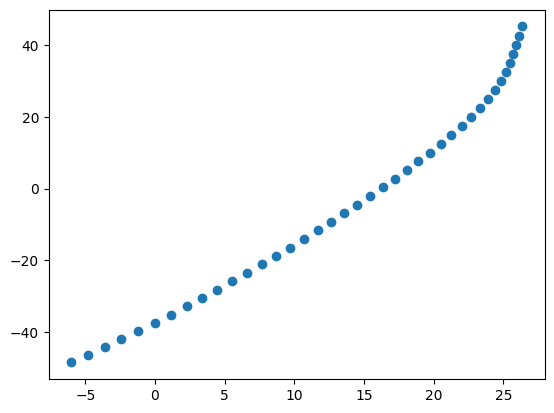

In [46]:
plt.scatter(z, other, label='Data Points')


In [47]:

d_dz = np.gradient(other, z)
d2_dz2 = np.gradient(d_dz, z)

def moving_average(data, window_size):
    """Simple moving average smoothing"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Smooth the coordinates
window = 3  # Adjust this (larger = more smoothing)
other_smooth = moving_average(other, window)
z_smooth = moving_average(z, window)

# Calculate derivatives on smoothed data
d_dz = np.gradient(other_smooth, z_smooth)
d2_dz2 = np.gradient(d_dz, z_smooth)

has_inflection = False
# Find inflection points
sign_changes = np.diff(np.sign(d2_dz2))
if np.any(sign_changes != 0):
    has_inflection = True


print(has_inflection)


False


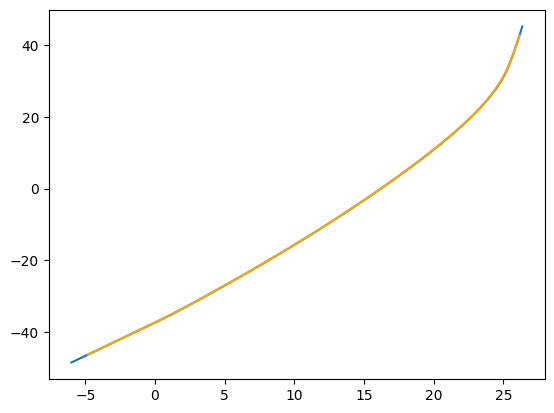

In [41]:
plt.plot(z, other, label='Data Points')
plt.plot(z_smooth, other_smooth, label='Smoothed Data', color='orange')

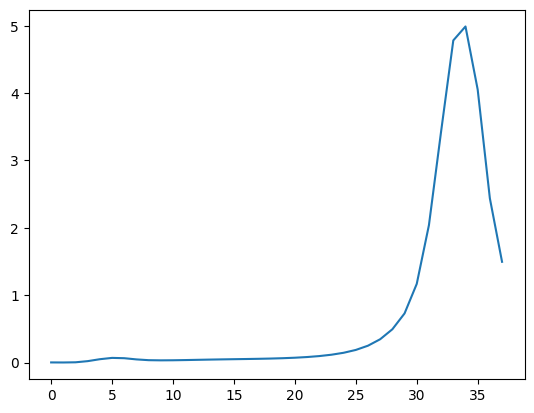

In [42]:
plt.plot(d2_dz2)